# <center><font color=navy>Data Science for Quantitative Finance</font></center>
## <center><font color=navy>Regression Recap and Asset Pricing Models</font> </center>
### <center> Ali Habibnia</center>

    
<center> Assistant Professor, Department of Economics, </center>
<center> and Division of Computational Modeling & Data Analytics at Virginia Tech</center>
<center> habibnia@vt.edu </center> 

### Readings:

1. ***Chapter 3.2***, [The Elements of Statistical Learning Data Mining, Inference, and Prediction](https://web.stanford.edu/~hastie/ElemStatLearn/printings/ESLII_print12.pdf)

2. For a quick review see: ***Chapter 9.2***, [Understanding Machine Learning From Theory to Algorithms](https://www.cs.huji.ac.il/~shais/UnderstandingMachineLearning/understanding-machine-learning-theory-algorithms.pdf)

3. For students with no background in Econometrics: [Econometric Data Science](https://www.sas.upenn.edu/~fdiebold/Textbooks.html)

4. For more advanced topics: ***Chapters 1-2 and 3.1-3.2***, J.D. Angrist and J.S. Pischke, Mostly Harmless Econometrics: An Empiricist’s Companion, Princeton University Press, 2009

5. Notations for Econometrics http://www.principlesofeconometrics.com/poe5/writing/abadir_magnus.pdf

### Python for Econometrics

1.  Kevin Sheppard, Oxford University https://www.kevinsheppard.com , https://www.kevinsheppard.com/files/teaching/python/notes/python_introduction_2020.pdf

2. Wooldridge's INTRODUCTORY ECONOMETRICS: A MODERN APPROACH https://www.cengage.com/c/introductory-econometrics-a-modern-approach-7e-wooldridge/9781337558860PF/, http://www.upfie.net, https://pypi.org/project/wooldridge/

### Motivation

Why are we learning linear regression?
- widely used
- runs fast
- easy to use (not a lot of tuning required)
- highly interpretable
- basis for many other methods

<div class="alert alert-block alert-info">
"[N]othing at all takes place in the universe in which some rule of maximum or minimum does not appear." 

-- Leonhard Euler

<img src="images/Leonhard_Euler.jpg"  width="220">
</div>




<img style="float: right;" src="images/error.png"  width="350">

Optimization problems arise in a large variety of contexts, including **econometrics**, and **machine learning**. The underlying mathematical problem always amounts to finding parameters that **minimize** (cost/loss) or **maximize** (utility/profit) an objective function in the presence or absence of a set of constraints.

Together, $\beta_0$ and $\beta_1$ are called the **model coefficients/parameters**. To create your model, you must "learn/estimate" the values of these coefficients. And once we've learned these coefficients, we can use the model to predict!

### Linear Regression


* Linear regression is an old method from statistics for describing the relationships between variables.

* LR is an algorithm for learning to predict a real-valued **target/dependent/response** variable as a linear function of one or more real-valued **input/explanatory/regressor/predictor/attribute/covariate/features...** variables. 

* LR is one of the most widely used statistical learning algorithms, and with care it can be made to work very well in practice. 

* There are different ways to describe and solve the linear regression problem. The most common way of solving linear regression is via a least squares optimization that is solved using matrix factorization methods from linear regression.

* Linear regression can be conveniently represented in terms of matrix-vector multiplication.

* Linear regression has a closed-form (analytical) solution in terms of basic linear algebra operations. This makes it a useful starting point for understanding many other statistical learning algorithms.

* In contrast to the models with a closed-form solution, sometimes we need an Iterative Optimization Algorithms to minimize or maximize an objective function. 

* The two basic types of regression are simple linear regression and multiple linear regression which are used for continuos variable, although there are non-linear regression methods like logistic regression which is used for classification problems among a few discrete values.

> Goals:

- Know the cost function for linear regression (e.g. least squares fit)
- Know of at least one method for fitting the model (e.g. gradient descent, closed-form solution)

Linear regression via the least squares method is the simplest approach to performing a regression analysis of a dependent and a explanatory variable. The objective is to find (mathematically) the best-fitting straight **line/plane/hyperplane** through a set of points that minimizes the sum of the squared **residuals/errors/offsets** from the line. 

The offsets come in 2 different flavors: perpendicular and vertical - with respect to the line.  
![](https://raw.githubusercontent.com/rasbt/python_reference/master/Images/least_squares_vertical.png)  
![](https://raw.githubusercontent.com/rasbt/python_reference/master/Images/least_squares_perpendicular.png)  

The perpendicular offset method delivers a more precise result but is are more complicated to handle. Therefore normally the vertical offsets are used.


$\newcommand{\vct}[1]{\mathbf{#1}}$
$\newcommand{\mtx}[1]{\mathbf{#1}}$
$\newcommand{\e}{\varepsilon}$
$\newcommand{\norm}[1]{\|#1\|}$
$\newcommand{\minimize}{\text{minimize}\quad}$
$\newcommand{\maximize}{\text{maximize}\quad}$
$\newcommand{\subjto}{\quad\text{subject to}\quad}$
$\newcommand{\R}{\mathbb{R}}$
$\newcommand{\trans}{T}$
$\newcommand{\ip}[2]{\langle {#1}, {#2} \rangle}$
Suppose we want to understand the relationship of a quantity $Y$ (for example, sales data) to a series of **predictors** $X_1,\dots,X_p$ (for example, advertising budget in different media). We can often assume the relationship to be **approximately linear**,

[1]\begin{equation*}
 Y = \beta_0+\beta_1 X_1 + \cdots + \beta_p X_p + \varepsilon, 
\end{equation*}

where $\varepsilon$ is some error or noise term. The goal is to determine the **model parameters** $\beta_0,\dots,\beta_p$.
To determine these, we can collect $n\geq p$ sample realizations (from observations or experiments),

\begin{equation*}
 Y=y_i, \quad X_1=x_{i1},\dots,X_p=x_{ip}, \quad 1\leq i\leq n,
\end{equation*}

and assume that the data is related according to [1], 

\begin{equation*}
 y_i = \beta_0+\beta_1x_{i1}+\cdots +\beta_p x_{ip}+\varepsilon_i, \quad 1\leq i\leq n.
\end{equation*}

Collecting the data in matrices and vectors,

\begin{equation*}
 \vct{y} = \begin{pmatrix}
            y_1\\ \vdots \\ y_n
           \end{pmatrix},
\quad \mtx{X} = \begin{pmatrix} 
           1 & x_{11} & \cdots & x_{1p}\\
           \vdots & \vdots & \ddots & \vdots \\
           1 & x_{n1} & \cdots & x_{np}
          \end{pmatrix},
\quad \vct{\beta} = \begin{pmatrix}
                     \beta_0\\
                     \beta_1\\
                     \vdots\\
                     \beta_p
                    \end{pmatrix},
\quad \vct{\varepsilon} = \begin{pmatrix}
                  \e_1\\
                  \vdots\\
                  \e_n
                 \end{pmatrix},
\end{equation*}

we can write the relationship concisely as 

\begin{equation*}
 \vct{y} = \mtx{X}\vct{\beta}+\vct{\e}.
\end{equation*}

We would then like to find $\vct{\beta}$ in such a way that the difference $\vct{\e}=\vct{y}-\mtx{X}\vct{\beta}$ is as *small* as possible. One way of measuring the size of a vector $\vct{\e}\in \R^n$ is the square of its **$2$-norm**, or Euclidean norm, 

\begin{equation*}
 \norm{\vct{\e}}_2^2=\vct{\e}^{T}\vct{\e}=\sum_{i=1}^n\e_i^2.
\end{equation*}

The best $\vct{\beta}$ is then the vector that solves the unconstrained optimization problem

\begin{equation*}
 \minimize \norm{\mtx{X}\vct{\beta}-\vct{y}}_2^2.
\end{equation*}

This is an example of an optimization problem, with variables $\vct{\beta}$, no constraints (*all* $\beta$ are valid candidates and the constraint set is $\Omega=\R^{p+1}$), and a **quadratic** objective function 

\begin{equation*}
f(\vct{\beta})=\norm{\mtx{X}\vct{\beta}-\vct{y}}_2^2 = (\mtx{X}\vct{\beta}-\vct{y})^{T}(\mtx{X}\vct{\beta}-\vct{y}) = \vct{\beta}^{T}\mtx{X}^{T}\mtx{X}\vct{\beta}-2\vct{y}^{T}\mtx{X}\vct{\beta}+\vct{y}^{T}\vct{y},
\end{equation*}

where $\mtx{X}^{T}$ is the matrix transpose.
Quadratic functions are convex, so this is a convex optimization problem.
This simple optimization problem has a **unique closed-form solution**,

This can be re-arranged in order to specify the solution for $\vct{\beta}$ as:

\begin{equation*}
 \vct{\beta}^* = (\vct{X}^{\trans}\vct{X})^{-1}\vct{X}^{\trans}\vct{y}.
\end{equation*}

In practice one wouldn't compute $\vct{\beta}^*$ by evaluating [1], as there are more efficient methods available. 

Bear in mind that the regression has six key assumptions:

1. Linear relationship between target and features
2. Data is normally distributed or contains Multivariate normality (but doesn't have to be)
3. No or little multicollinearity
4. No auto-correlation
5. Homoscedasticity
6. Independent features

### Python libraries for Regression Analysis

In this section, first, we will see how to solve linear regression via closed-form solution and the least-squares solution from scrach by using numpy.

Then we will be using [Statsmodels](http://statsmodels.sourceforge.net/) for linear modeling. However, I recommend that you spend most of your energy on [scikit-learn](http://scikit-learn.org/stable/) since it provides significantly more useful functionality for machine learning in general.

#### Requirements for Working With Data in scikit-learn

1. Features and response should be separate objects.
2. Features and response should be entirely numeric.
3. Features and response should be NumPy arrays (or easily converted to NumPy arrays).
4. Features and response should have specific shapes (outlined below).
5. Note that **p-values** and **confidence intervals** are not (easily) accessible.

In [1]:
%matplotlib inline 

# %matplotlib (percent sign) is a magic function in IPython (Jupyter Notebook). 
# this allows plots to appear directly in the notebook.

[[0.05 0.12]
 [0.18 0.22]
 [0.31 0.35]
 [0.42 0.38]
 [0.5  0.49]]


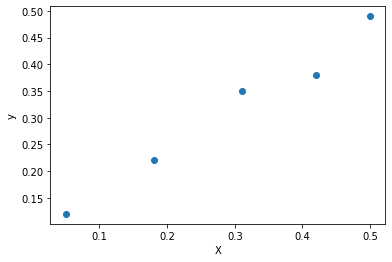

In [2]:
# linear regression 

'''
    NumPy is a library for multi-dimensional arrays and matrices along with a large collection
    of mathematical functions to operate on these arrays.
    
    Matplotlib is a plotting library for the Python programming language  
'''


import numpy as np
import matplotlib.pyplot as plt
# define dataset

'''
X = [x_i*random.randrange(8,12)/10 for x_i in range(500)]
y = [y_i*random.randrange(8,12)/10 for y_i in range(100,600)]
'''

data = np.array([
  [0.05, 0.12],
  [0.18, 0.22],
  [0.31, 0.35],
  [0.42, 0.38],
  [0.5, 0.49]])
print(data)

# split into inputs and outputs
X, y = data[:,0], data[:,1]
X = X.reshape((len(X), 1))

# scatter plot
plt.scatter(X, y)
plt.ylabel('y')
plt.xlabel('X')
plt.show()

Beta = [1.00233226]


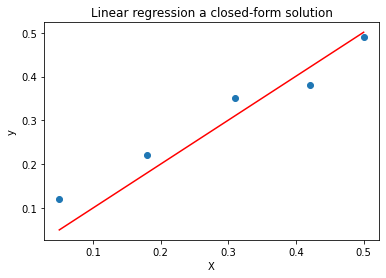

In [3]:
# direct solution to linear least squares
import numpy as np
import matplotlib.pyplot as plt
# define dataset
data = np.array([
  [0.05, 0.12],
  [0.18, 0.22],
  [0.31, 0.35],
  [0.42, 0.38],
  [0.5, 0.49]])
# print(data)
# split into inputs and outputs
X, y = data[:,0], data[:,1]
X = X.reshape((len(X), 1))
# linear least squares

b = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)

print("Beta =", b)
# predict using coefficients
yhat = X.dot(b)
# plot data and predictions
plt.scatter(X, y) 
plt.plot(X, yhat, color='red') 
plt.ylabel('y')
plt.xlabel('X')
plt.title('Linear regression a closed-form solution')
plt.show()

In [4]:
""" Build a function to compute the closed-form solution to a linear matrix equation. """
import numpy as np

def OLS(x, y):
    X = np.vstack([x, np.ones(len(x))]).T
    return (np.linalg.inv(X.T.dot(X)).dot(X.T)).dot(y)

## Least Squares Estimation for Simple Linear Regression

As we mentioned in the previous sectoin, the parameters $\beta_0$ and $\beta_1$ are unknown, and we have to estimate them by using sample data points. Suppose we have N paires of $x$ and $y$. There are infinite number of lines that we can use, but we are looking for selecting the best line through the data. <br>
We have to estimate the parameters in way that we minimize the difference between the data points which is $y_i$ and the value of straight line in the certain $x$ point. From now, we called this diffrences as **residual** and we show it by $e_i$. Residual play an important role in evaluating the accuracy of the model. We will talk more about it the next section. We use $\hat{y}$ to show the regression value to distinguish the observed value of $y$ from the value that calculated from the regression model.
So <br>
$$SS_{res}=\sum{e_i}^2=\sum\limits_{i=1}^n{(y_i-\hat{y_i})^2}=\sum\limits_{i=1}^n(y_i-(\hat{\beta_0}+\hat{\beta_1}x_i))^2$$ <br>
We call the above equition the **sum of squares for the residuals ($SS_{res}$)**. Our best estimated line, then, is the one which minimizes the $SS_{res}$. <br> <br>
Minimizing $e$ amounts to solving the so-called normal equations<br>
$$\frac{\partial SS_{res}}{\partial \hat{\beta_0}}=-2\sum\limits_{i=1}^n[y_i-\hat{\beta_0}-\hat{\beta_1}x_i]=0$$ <br>
$$\frac{\partial SS_{res}}{\partial \hat{\beta_1}}=-2\sum\limits_{i=1}^n[x_iy_i-\hat{\beta_0}x_i-\hat{\beta_1}x_i^2]=0$$ <br>
That is, <br>
$$n\hat{\beta_0}+\hat{\beta_1}\sum\limits_{i=1}^n{x_i}=\sum\limits_{i=1}^n{y_i}$$ <br> 
and <br>
$$\hat{\beta_0}\sum\limits_{i=1}^n{x_i}+\hat{\beta_1}\sum\limits_{i=1}^n{x_i^2}=\sum\limits_{i=1}^n{x_iy_i}$$ <br>
Let $$\bar{x}=\frac{1}{n}\sum\limits_{i=1}^n{x_i}$$ and $$\bar{y}=\frac{1}{n}\sum\limits_{i=1}^n{y_i}$$ be the sample means of predictor values
and the responses. If <br>
$$S_{xy}=\sum\limits_{i=1}^n{(x_i-\bar{x})(y_i-\bar{y})}=\sum\limits_{i=1}^ny_i(x_i-\bar{x})=\sum\limits_{i=1}^nx_iy_i-n\bar{x}\bar{y}$$ <br>
$$S_{xx} = \sum\limits_{i=1}^n{(x_i-\bar{x})}^2=\sum\limits_{i=1}^n{x_i}^2-n\bar{x}^2$$ <br>
$SS_{xx}$ is the sum of the squares of the difference between each 𝑥 and the mean 𝑥 value, and <br>
$SS_{xy}$ is sum of the product of the difference between 𝑥 its means and the difference between 𝑦 and its mean.
$$S_{yy} = \sum\limits_{i=1}^n{(y_i-\bar{y})}^2=\sum\limits_{i=1}^n{y_i}-n\bar{y}^2$$ <br>
then the values for $\hat{\beta_0}$ and $\hat{\beta_1}$ minimizing $e$ or, equivalently, solving the
normal equations are <br>
$$\hat{\beta_0}=\bar{y}-\hat{\beta_1}\bar{x}$$ <br>
$$\hat{\beta_1}=\frac{S_{xy}}{S_{xx}}$$


### The classic approach in Python

$\beta_1 = \frac{S_{xy}}{\sigma_{x}^{2}}\quad$  (slope/coefficient)


$\beta_0 = \bar{y} - \beta_1\bar{x}\quad$ (y-axis intercept)

where 


$S_{xy} = \sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})\quad$ (covariance)


$\sigma{_x}^{2} = \sum_{i=1}^{n} (x_i - \bar{x})^2\quad$ (variance)

In [5]:
""" Build a function to compute the least-squares solution to a linear matrix equation. """

def classic_lstsqr(x_list, y_list):
    N = len(x_list)
    x_avg = sum(x_list)/N
    y_avg = sum(y_list)/N
    var_x, cov_xy = 0, 0
    for x,y in zip(x_list, y_list):
        temp = x - x_avg
        var_x += temp**2
        cov_xy += temp * (y - y_avg)
    slope = cov_xy / var_x
    y_interc = y_avg - slope*x_avg
    return (slope, y_interc)

## Asset Pricing Models and Their Role in Finance

Asset pricing models play a fundamental role in financial economics by helping investors, analysts, and policymakers understand how financial assets are priced in equilibrium. These models attempt to quantify the relationship between **risk and expected return**, forming the foundation for:

- **Portfolio Management**: Determining the optimal asset allocation based on risk and return trade-offs.
- **Cost of Capital Estimation**: Assisting firms in computing their cost of equity capital, which is crucial for corporate finance decisions.
- **Risk Assessment**: Understanding how different risk factors drive asset returns, aiding in better risk management.
- **Market Efficiency Analysis**: Evaluating whether asset prices reflect available information (Efficient Market Hypothesis).

The **Capital Asset Pricing Model (CAPM)** was one of the earliest and most influential asset pricing models, forming the basis for more advanced multi-factor models such as the **Fama-French three-factor model**, the **five-factor model**, and more recent **machine learning-based models**.


### The Capital Asset Pricing Model (CAPM)

The **Capital Asset Pricing Model (CAPM)** is a single-factor model that explains the expected return of an asset as a function of its exposure to market risk. It is based on the principle that investors are only compensated for systematic risk (non-diversifiable risk), as idiosyncratic risk (firm-specific risk) can be eliminated through diversification.

The model is mathematically represented as:

$$
r_i = r_f + \beta_i (r_m - r_f)
$$

where:

- $r_i$ = Expected return of asset $i$
- $r_f$ = Risk-free rate (e.g., U.S. Treasury bills)
- $r_m$ = Expected return of the market portfolio (e.g., S&P 500)
- $\beta_i$ = Sensitivity (beta) of asset $i$ to the market
- $(r_m - r_f)$ = Market risk premium (compensation for bearing market risk)

### **Interpreting the Components of CAPM**
- **Risk-Free Rate ($r_f$)**: Represents the time value of money and the minimum return investors expect.
- **Market Risk Premium ($r_m - r_f$)**: The excess return investors demand for holding a risky market portfolio over a risk-free asset.
- **Beta ($\beta_i$)**: Measures the **systematic risk** of an asset relative to the market.
  - If $\beta > 1$, the asset is more volatile than the market.
  - If $\beta < 1$, the asset is less volatile than the market.
  - If $\beta = 1$, the asset moves in sync with the market.

### **Underlying Assumptions of CAPM**
1. **Investors hold well-diversified portfolios**, eliminating idiosyncratic risk.
2. **Markets are frictionless** (no transaction costs, short-selling restrictions, or taxes).
3. **Investors are rational** and maximize expected utility.
4. **A single-period investment horizon** applies.
5. **Risk is captured by beta**, meaning only systematic risk matters.

CAPM was independently developed by William F. Sharpe (1964), John Lintner (1965), and Jan Mossin (1966), building on Harry Markowitz’s (1952) portfolio theory. Below are key references for its original formulation:

1. Sharpe, William F. (1964).
    Capital Asset Prices: A Theory of Market Equilibrium under Conditions of Risk.
    The Journal of Finance, 19(3), 425-442.

2. Lintner, John (1965).
    The Valuation of Risk Assets and the Selection of Risky Investments in Stock Portfolios and Capital Budgets.
    The Review of Economics and Statistics, 47(1), 13-37.

3. Mossin, Jan (1966).
    Equilibrium in a Capital Asset Market.
    Econometrica, 34(4), 768-783.

4. Treynor, Jack L. (1961, unpublished manuscript).
    Market Value, Time, and Risk.
    Though unpublished, Treynor independently contributed to CAPM development.

5. Markowitz, Harry (1952).
    Portfolio Selection.
    The Journal of Finance, 7(1), 77-91.


The goal of the CAPM formula is to evaluate whether a stock is fairly valued when its risk and the time value of money are compared to its expected return. Although widely used, these assumptions are often challenged, leading to more sophisticated models like the **Fama-French factor models**.


### Factor Investing and the Fama-French Models

**Factor investing** is a quantitative approach to asset pricing that extends beyond traditional **single-factor models** (such as CAPM) by incorporating multiple risk factors that drive stock returns. The idea is that stocks with **similar characteristics** exhibit **systematic risk premiums** over time.

### **Types of Risk Factors**
Academic research has identified **multiple factors** that explain asset returns:

1. **Market Factor** – Systematic risk, as in CAPM.
2. **Size Factor (SMB: Small Minus Big)** – Small-cap stocks tend to outperform large-cap stocks.
3. **Value Factor (HML: High Minus Low)** – Stocks with high book-to-market ratios (value stocks) outperform low book-to-market stocks (growth stocks).
4. **Momentum Factor (UMD: Up Minus Down)** – Stocks that have performed well in the past continue to do so.
5. **Profitability Factor (RMW: Robust Minus Weak)** – Profitable firms tend to outperform less profitable ones.
6. **Investment Factor (CMA: Conservative Minus Aggressive)** – Firms with conservative investment strategies tend to outperform aggressive ones.

The **Fama-French models** build on these factors to better capture expected returns.


### Fama-French Three-Factor Model (FF3)

The **Fama-French Three-Factor Model** (1993) extends CAPM by introducing two additional factors: **size** and **value**.

The regression equation is:

$$
r_{it} - r_{ft} = \alpha_{it} + \beta_1 (r_{mt} - r_{ft}) + \beta_2 SMB_t + \beta_3 HML_t + \epsilon_{it}
$$

where:

- $r_{it}$ = Return on stock $i$ at time $t$
- $r_{ft}$ = Risk-free rate
- $r_{mt}$ = Return on the market portfolio
- $SMB_t$ = Return spread between small and large stocks (**size factor**)
- $HML_t$ = Return spread between high book-to-market and low book-to-market stocks (**value factor**)
- $\alpha_{it}$ = Intercept (abnormal return)
- $\epsilon_{it}$ = Idiosyncratic error term
- $\beta_1, \beta_2, \beta_3$ = Sensitivity to respective risk factors

### **Interpretation of FF3 Factors**
- **SMB (Small Minus Big)**: Measures the premium investors receive for investing in small-cap stocks.
- **HML (High Minus Low)**: Reflects the excess return of value stocks over growth stocks.

The model **explains more variation in stock returns** than CAPM, particularly for **small-cap and value stocks**.

### **Limitations of FF3**
- It does not account for **momentum effects** (Jegadeesh & Titman, 1993).
- The explanatory power varies across different time periods and regions.


### Fama-French Five-Factor Model (FF5)

To address weaknesses in FF3, **Fama and French (2015)** introduced the **Five-Factor Model**, adding **profitability** and **investment** factors.

The model is given by:

$$
r_{it} - r_{ft} = \alpha_{it} + \beta_1 (r_{mt} - r_{ft}) + \beta_2 SMB_t + \beta_3 HML_t + \beta_4 RMW_t + \beta_5 CMA_t + \epsilon_{it}
$$

where:

- $RMW$ (Robust Minus Weak) = Return spread between highly profitable firms and less profitable firms.
- $CMA$ (Conservative Minus Aggressive) = Return spread between firms with conservative vs. aggressive investment policies.

### **Economic Rationale for FF5**
- **Profitability ($RMW$)**: More profitable firms generate higher returns.
- **Investment ($CMA$)**: Firms investing **aggressively** (high asset growth) tend to underperform those with **conservative** investment strategies.

### **Advantages of FF5**
- Reduces unexplained **anomalies** observed in FF3.
- Provides better pricing accuracy for stock returns.

### **Criticism of FF5**
- **HML’s diminishing significance**: Some research suggests that the value factor (HML) becomes redundant after adding RMW and CMA.
- **Missing momentum factor**: FF5 does not explicitly account for momentum (addressed by Carhart’s Four-Factor Model).



| Model         | Return Notation | Explanation |
|--------------|---------------|-------------|
| **CAPM** | $r_i$ | Assumes a **static** risk-return relationship with a **constant beta** ($\beta_i$). Estimated cross-sectionally. |
| **Fama-French** | $r_{it}$ | Uses **time-series regression** where factor returns **change over time** ($t$). Allows for **time-varying risk premia**. |

#### **References**
- Sharpe (1964), *The Journal of Finance*  
- Fama & French (1993), *Journal of Financial Economics*  
- Fama & French (2015), *Journal of Financial Economics*


## Other Prominent Asset Pricing Models

Beyond **CAPM** and **Fama-French models**, several other **multi-factor and alternative asset pricing models** have been developed to explain asset returns more accurately.

---

 **Carhart Four-Factor Model (1997)**
 **Momentum in Asset Pricing **
 
Carhart (1997) extends the **Fama-French Three-Factor Model** by adding a **momentum factor** ($UMD$):

$$
r_{it} - r_{ft} = \alpha_{it} + \beta_1 (r_{mt} - r_{ft}) + \beta_2 SMB_t + \beta_3 HML_t + \beta_4 UMD_t + \epsilon_{it}
$$

- **UMD (Up Minus Down)**: Return spread between past **winners (high-performing stocks)** and **losers (low-performing stocks)**.
- Stocks with **positive past returns tend to continue outperforming** (momentum effect).
- **Empirical evidence** suggests that momentum is **not explained by size or value factors**.

 **Criticism**
- **Momentum crashes**: Strong reversals occur in bear markets.
- Hard to justify within a **rational risk-based framework**.

**Reference:**  
- Carhart, M. M. (1997). *On persistence in mutual fund performance.* *The Journal of Finance, 52*(1), 57-82.

---

** Q-Factor Model (Hou, Xue, Zhang, 2015)**
** Profitability & Investment-Based Asset Pricing**
The **Q-Factor Model** refines **Fama-French 5-Factor** by focusing on:
1. **Market Excess Return ($r_m - r_f$)**  
2. **Size (SMB)**  
3. **Investment (CMA)** – Conservative vs. aggressive investment firms  
4. **Profitability (RMW)** – High vs. low profitability firms  

$$
r_{it} - r_{ft} = \alpha_{it} + \beta_1 (r_{mt} - r_{ft}) + \beta_2 SMB_t + \beta_3 RMW_t + \beta_4 CMA_t + \epsilon_{it}
$$

- Excludes the **value factor (HML)**, arguing it lacks independent explanatory power.
- **Stronger empirical support** than Fama-French in some regions.

**Reference:**  
- Hou, K., Xue, C., & Zhang, L. (2015). *Digesting anomalies: An investment approach.* *The Review of Financial Studies, 28*(3), 650-705.

---

**Arbitrage Pricing Theory (APT, Ross 1976)**
**A Multi-Factor Alternative to CAPM**
APT posits that **asset returns are driven by multiple systematic risk factors**:

$$
r_i = r_f + \sum_{k=1}^{K} \beta_k f_k + \epsilon_i
$$

where **$f_k$** are risk factors (e.g., inflation, interest rates, economic growth).

- Unlike CAPM, **APT does not specify what the risk factors are**.
- Uses **statistical techniques (e.g., PCA, factor analysis)** to identify key drivers of asset returns.
- More flexible but **less practical for direct portfolio applications**.

**Reference:**  
- Ross, S. A. (1976). *The arbitrage theory of capital asset pricing.* *Journal of Economic Theory, 13*(3), 341-360.

---

**Consumption-Based Asset Pricing Model (C-CAPM)**
**Linking Asset Prices to Consumption Growth**
C-CAPM extends CAPM by **linking asset prices to macroeconomic fundamentals**:

$$
E[r_i] - r_f = \beta_i E_m
$$

where $\beta_i$ is **exposure to aggregate consumption risk**.

- Investors require compensation for **assets that perform poorly in bad economic times**.
- Explains stock market behavior but **faces empirical challenges**.

**Reference:**  
- Breeden, D. T. (1979). *An intertemporal asset pricing model with stochastic consumption and investment opportunities.* *Journal of Financial Economics, 7*(3), 265-296.

---

**Stochastic Discount Factor (SDF) Approach**
A **unifying framework** for asset pricing:

$$
E[M r_i] = 1
$$

where **$M$** is the **stochastic discount factor** (SDF), also called the **pricing kernel**.

- Many models (CAPM, APT, C-CAPM) can be **derived from SDF**.
- **Advantage**: The most **general representation** of asset pricing.

**Reference:**  
- Cochrane, J. H. (2005). *Asset Pricing.* Princeton University Press.

---

## **Summary Table: Comparison of Asset Pricing Models**

| Model | Factors | Strengths | Weaknesses |
|------|---------|-----------|------------|
| **CAPM** | Market | Simple, intuitive | Empirically weak |
| **Fama-French 3-Factor** | Market, Size, Value | Explains size & value premiums | Ignores momentum |
| **Carhart 4-Factor** | Market, Size, Value, Momentum | Accounts for momentum | Momentum crashes |
| **Fama-French 5-Factor** | Market, Size, Value, Profitability, Investment | Better explanatory power | Value factor loses relevance |
| **Q-Factor Model** | Market, Size, Profitability, Investment | Strong empirical performance | Ignores value factor |
| **APT** | Multiple macroeconomic factors | Flexible, multi-factor | No clear factor specification |
| **C-CAPM** | Consumption risk | Theoretically strong | Empirical difficulties |
| **SDF Approach** | General | Unifying framework | Hard to estimate |


## Statistical Analysis with statsmodels

https://www.statsmodels.org

statsmodels provides a large range of cross-sectional models as well as some time-series models. Basic linear regression is provided by OLS. Estimating a model requires specifying the model and then calling a method to estimate the parameters (named fit in most models). 

In [1]:
! pip install yfinance > NUL
! pip install pandas-datareader --upgrade > NUL

In [6]:
import yfinance as yf
import bs4 as bs
import numpy as np
import os
import requests
import pandas as pd
import datetime
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import statsmodels.formula.api as sm # module for stats models
from statsmodels.iolib.summary2 import summary_col # module for presenting stats models outputs nicely
%matplotlib inline

import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)

In [7]:
### Historical Stock Price Data

resp = requests.get('http://en.wikipedia.org/wiki/List_of_S%26P_500_companies')
soup = bs.BeautifulSoup(resp.text, 'lxml')
table = soup.find('table', {'class': 'wikitable sortable'})
tickers = []
for row in table.findAll('tr')[1:]:
    ticker = row.findAll('td')[0].text
    tickers.append(ticker)

tickers = [s.replace('\n', '') for s in tickers]
start = datetime.datetime(2006,1,1)
end = datetime.datetime(2020,6,30)
tickers=tickers+["SPY"];

data = yf.download(tickers, start=start, end=end)['Adj Close']

print(data)

[*********************100%***********************]  504 of 504 completed

5 Failed downloads:
- BF.B: No data found for this date range, symbol may be delisted
- OGN: Data doesn't exist for startDate = 1136091600, endDate = 1593489600
- CEG: Data doesn't exist for startDate = 1136091600, endDate = 1593489600
- BRK.B: No data found, symbol may be delisted
- GEHC: Data doesn't exist for startDate = 1136091600, endDate = 1593489600
                    A        AAL         AAP       AAPL       ABBV        ABC  \
Date                                                                            
2006-01-03  20.400560  35.305664   38.423595   2.265983        NaN  16.258938   
2006-01-04  20.455357  36.955463   38.697315   2.272653        NaN  16.151209   
2006-01-05  20.991257  37.436260   38.882702   2.254768        NaN  15.951151   
2006-01-06  21.100876  36.766918   38.838551   2.312970        NaN  15.774172   
2006-01-09  21.039982  36.399254   39.341808   2.305391        NaN  15.774172   


In [8]:
if not os.path.exists('Stock_Data'):
    os.makedirs('Stock_Data')
data.to_csv('Stock_Data/SP500Prices.csv')

#data.to_hdf('Stock_Data/SP500Prices.h5', 'fixed', mode='w', complib='blosc', complevel=9)

In [9]:
cleaned_data = data.copy()

# Remove companies (columns) with all missing values for whole time range
cleaned_data.dropna(axis='columns', how='all', inplace=True)

# Remove days (rows) with missing values for all of companies
cleaned_data.dropna(axis='index', how='all', inplace=True)

# Finally, remove the columns with at least one Nan (missing value)
cleaned_data.dropna(axis='columns', how='any', inplace=True)

cleaned_data

,A,AAL,AAP,AAPL,ABC,ABT,ACGL,ACN,ADBE,ADI,...,WTW,WY,WYNN,XEL,XOM,XRAY,YUM,ZBH,ZBRA,ZION
Date,,,,,,,,,,,,,,,,,,,,,
2006-01-03,20.400560,35.305664,38.423595,2.265983,16.258938,12.530259,6.120000,21.450239,38.520000,23.851408,...,64.403900,13.357165,29.625664,9.751626,32.048004,23.966692,12.062395,60.362865,42.830002,56.404537
2006-01-04,20.455357,36.955463,38.697315,2.272653,16.151209,12.549263,6.151111,21.567379,38.419998,24.072374,...,65.072762,13.679873,29.570749,9.798885,32.102802,24.188478,12.165599,60.935837,42.410000,56.802811
2006-01-05,20.991257,37.436260,38.882702,2.254768,15.951151,12.710846,6.061111,21.728443,38.070000,24.839266,...,64.087074,13.559610,29.395031,9.793634,31.943861,23.913458,12.684220,60.292362,42.529999,57.319096
2006-01-06,21.100876,36.766918,38.838551,2.312970,15.774172,12.954793,6.173333,22.804605,39.000000,24.936747,...,63.312599,13.579657,29.675089,9.830395,32.574192,24.286070,12.648103,59.983845,44.119999,57.916447
2006-01-09,21.039982,36.399254,39.341808,2.305391,15.774172,13.436364,6.116667,22.738722,38.380001,25.287697,...,65.882416,13.547583,31.075380,9.804136,32.557747,24.525604,12.746144,62.108185,44.790001,57.437077
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-06-23,87.422417,14.000000,139.826126,89.843628,97.086075,86.546471,29.559999,198.269089,440.549988,116.737549,...,185.444489,19.926138,84.096046,58.997757,39.540314,43.215523,83.275253,119.415413,260.769989,31.866991
2020-06-24,84.758995,13.040000,133.327560,88.257690,94.541733,82.754738,28.450001,192.953873,431.679993,113.157280,...,182.452225,19.033527,74.841599,58.529015,37.677601,41.371834,81.987091,112.077583,250.500000,29.837135
2020-06-25,85.444443,13.170000,133.243652,89.429359,96.292152,84.953941,28.879999,207.752365,436.950012,113.753990,...,190.539932,19.243555,73.199677,57.812103,38.244884,41.429882,81.456696,109.309280,253.639999,30.762249


In [10]:
# This converts prices to arithmetic or log returns.

prices = cleaned_data.copy()
return_values = np.log(prices).diff().dropna()
print(return_values.shape)
return_values.head(10)

(3646, 417)


,A,AAL,AAP,AAPL,ABC,ABT,ACGL,ACN,ADBE,ADI,...,WTW,WY,WYNN,XEL,XOM,XRAY,YUM,ZBH,ZBRA,ZION
Date,,,,,,,,,,,,,,,,,,,,,
2006-01-04 00:00:00,0.002682,0.045670,0.007098,0.002939,-0.006648,0.001515,0.005071,0.005446,-0.002599,0.009222,...,0.010332,0.023873,-0.001855,0.004835,0.001708,0.009211,0.008519,0.009447,-0.009855,0.007036
2006-01-05 00:00:00,0.025861,0.012926,0.004779,-0.007900,-0.012464,0.012794,-0.014740,0.007440,-0.009152,0.031361,...,-0.015263,-0.008830,-0.005960,-0.000536,-0.004963,-0.011435,0.041747,-0.010616,0.002826,0.009048
2006-01-06 00:00:00,0.005209,-0.018041,-0.001136,0.025485,-0.011157,0.019010,0.018346,0.048340,0.024135,0.003917,...,-0.012158,0.001477,0.009482,0.003746,0.019540,0.015462,-0.002852,-0.005130,0.036703,0.010368
2006-01-09 00:00:00,-0.002890,-0.010050,0.012874,-0.003282,0.000000,0.036499,-0.009222,-0.002893,-0.016025,0.013976,...,0.039787,-0.002365,0.046108,-0.002675,-0.000505,0.009815,0.007722,0.034803,0.015072,-0.008311
2006-01-10 00:00:00,0.012940,-0.021202,0.001122,0.061329,0.000243,-0.009715,0.006338,-0.021807,0.005975,0.000000,...,-0.010204,0.013228,0.001236,0.004809,0.007714,-0.008537,-0.000810,-0.004267,0.036607,-0.011753
2006-01-11 00:00:00,-0.000286,-0.082691,-0.008555,0.036906,-0.000243,-0.007095,0.003424,0.008193,0.018476,0.004871,...,-0.004599,-0.000585,0.029562,-0.007491,0.006826,0.022724,-0.008053,0.025749,-0.009516,0.005829
2006-01-12 00:00:00,-0.022252,0.005445,0.002935,0.004638,0.007774,-0.002175,-0.008128,-0.001634,0.003807,-0.008476,...,0.017471,-0.017686,-0.009469,0.010152,-0.010508,-0.001606,-0.016304,0.005955,0.010591,-0.015228
2006-01-13 00:00:00,-0.007627,-0.027232,0.000225,0.015306,0.002418,-0.003635,-0.005820,-0.012500,-0.016344,0.006428,...,-0.004807,-0.011516,0.009297,0.000532,0.022056,0.004988,-0.000208,-0.025453,-0.007554,0.010307
2006-01-17 00:00:00,-0.005907,-0.126633,-0.019573,-0.010335,-0.012389,-0.002917,-0.016183,0.020640,0.015330,-0.031236,...,-0.014564,0.001052,-0.025164,0.011096,0.009306,-0.004096,-0.012355,0.001416,-0.020132,-0.004814


In [11]:
def assetPriceReg(df_stk):
    import pandas_datareader.data as web  # module for reading datasets directly from the web
    
    # Reading in factor data
    df_factors = web.DataReader('F-F_Research_Data_5_Factors_2x3_daily', 'famafrench')[0]
    df_factors.rename(columns={'Mkt-RF': 'MKT'}, inplace=True)
    df_factors['MKT'] = df_factors['MKT']/100
    df_factors['SMB'] = df_factors['SMB']/100
    df_factors['HML'] = df_factors['HML']/100
    df_factors['RMW'] = df_factors['RMW']/100
    df_factors['CMA'] = df_factors['CMA']/100
    
    df_stock_factor = pd.merge(df_stk,df_factors,left_index=True,right_index=True) # Merging the stock and factor returns dataframes together
    df_stock_factor['XsRet'] = df_stock_factor['Returns'] - df_stock_factor['RF'] # Calculating excess returns

    # Running CAPM, FF3, and FF5 models.
    CAPM = sm.ols(formula = 'XsRet ~ MKT', data=df_stock_factor).fit(cov_type='HAC',cov_kwds={'maxlags':1})
    FF3 = sm.ols( formula = 'XsRet ~ MKT + SMB + HML', data=df_stock_factor).fit(cov_type='HAC',cov_kwds={'maxlags':1})
    FF5 = sm.ols( formula = 'XsRet ~ MKT + SMB + HML + RMW + CMA', data=df_stock_factor).fit(cov_type='HAC',cov_kwds={'maxlags':1})

    CAPMtstat = CAPM.tvalues
    FF3tstat = FF3.tvalues
    FF5tstat = FF5.tvalues

    CAPMcoeff = CAPM.params
    FF3coeff = FF3.params
    FF5coeff = FF5.params

    # DataFrame with coefficients and t-stats
    results_df = pd.DataFrame({'CAPMcoeff':CAPMcoeff,'CAPMtstat':CAPMtstat,
                               'FF3coeff':FF3coeff, 'FF3tstat':FF3tstat,
                               'FF5coeff':FF5coeff, 'FF5tstat':FF5tstat},
    index = ['Intercept', 'MKT', 'SMB', 'HML', 'RMW', 'CMA'])


    dfoutput = summary_col([CAPM,FF3, FF5],stars=True,float_format='%0.4f',
                  model_names=['CAPM','FF3','FF5'],
                  info_dict={'N':lambda x: "{0:d}".format(int(x.nobs)),
                             'Adjusted R2':lambda x: "{:.4f}".format(x.rsquared_adj)}, 
                             regressor_order = ['Intercept', 'MKT', 'SMB', 'HML', 'RMW', 'CMA'])

    print(dfoutput)
    
    return results_df

In [12]:
df_stk = yf.download('NVDA', start=start, end=end)
df_stk.head()

[*********************100%***********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2006-01-03,3.064167,3.208333,3.054167,3.185000,2.922242,47281200
2006-01-04,3.209167,3.279167,3.175833,3.274167,3.004054,51007200
2006-01-05,3.275000,3.354167,3.269167,3.348333,3.072100,64609200
2006-01-06,3.386667,3.415833,3.254167,3.403333,3.122564,62338800
2006-01-09,3.401667,3.516667,3.394167,3.498333,3.209726,56048400


<AxesSubplot:xlabel='Date'>

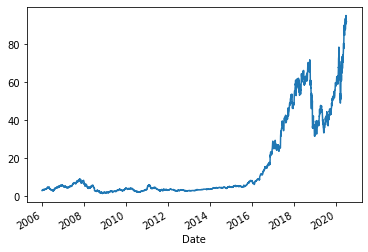

In [13]:
df_stk.drop(['Volume'],axis=1,inplace=True)
df_stk['Adj Close'].plot()

In [14]:
df_stk['Returns'] = np.log(df_stk[['Adj Close']]).diff().dropna()
df_stk.head()

,Open,High,Low,Close,Adj Close,Returns
Date,,,,,,
2006-01-03,3.064167,3.208333,3.054167,3.185000,2.922242,NaN
2006-01-04,3.209167,3.279167,3.175833,3.274167,3.004054,0.027611
2006-01-05,3.275000,3.354167,3.269167,3.348333,3.072100,0.022399
2006-01-06,3.386667,3.415833,3.254167,3.403333,3.122564,0.016293
2006-01-09,3.401667,3.516667,3.394167,3.498333,3.209726,0.027531


<AxesSubplot:xlabel='Date'>

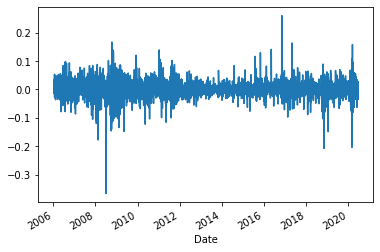

In [15]:
df_stk['Returns'].plot()

<AxesSubplot:>

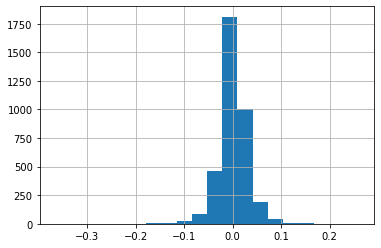

In [16]:
df_stk['Returns'].hist(bins=20)

In [17]:
df_stk['Returns'].describe()

count    3646.000000
mean        0.000945
std         0.030545
min        -0.367108
25%        -0.013310
50%         0.001139
75%         0.015712
max         0.260876
Name: Returns, dtype: float64

In [18]:
df_regOutput = assetPriceReg(df_stk)


                  CAPM       FF3        FF5    
-----------------------------------------------
Intercept      -0.0067*** -0.0075*** -0.0075***
               (0.0012)   (0.0011)   (0.0011)  
MKT            1.5120***  1.6305***  1.4925*** 
               (0.0707)   (0.0637)   (0.0684)  
SMB                       0.5429***  0.3230*** 
                          (0.1235)   (0.1222)  
HML                       -1.0400*** -0.7702***
                          (0.1092)   (0.1168)  
RMW                                  0.6162*   
                                     (0.3413)  
CMA                                  -1.5601***
                                     (0.3989)  
R-squared      0.5343     0.6073     0.6250    
R-squared Adj. 0.5333     0.6047     0.6209    
N              464        464        464       
Adjusted R2    0.5333     0.6047     0.6209    
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01


In [19]:
    import pandas_datareader.data as web  # module for reading datasets directly from the web
    
    # Reading in factor data
    df_factors = web.DataReader('F-F_Research_Data_5_Factors_2x3_daily', 'famafrench')[0]
    df_factors.rename(columns={'Mkt-RF': 'MKT'}, inplace=True)
    df_factors['MKT'] = df_factors['MKT']/100
    df_factors['SMB'] = df_factors['SMB']/100
    df_factors['HML'] = df_factors['HML']/100
    df_factors['RMW'] = df_factors['RMW']/100
    df_factors['CMA'] = df_factors['CMA']/100
    
    df_stock_factor = pd.merge(df_stk,df_factors,left_index=True,right_index=True) # Merging the stock and factor returns dataframes together
    df_stock_factor['XsRet'] = df_stock_factor['Returns'] - df_stock_factor['RF'] # Calculating excess returns

    # Running CAPM, FF3, and FF5 models.
    FF5 = sm.ols( formula = 'XsRet ~ MKT + SMB + HML + RMW + CMA', data=df_stock_factor).fit(cov_type='HAC',cov_kwds={'maxlags':1})

In [20]:
FF5.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  XsRet   R-squared:                       0.625
Model:                            OLS   Adj. R-squared:                  0.621
Method:                 Least Squares   F-statistic:                     152.8
Date:                Wed, 23 Aug 2023   Prob (F-statistic):           3.36e-95
Time:                        00:56:33   Log-Likelihood:                 1117.6
No. Observations:                 464   AIC:                            -2223.
Df Residuals:                     458   BIC:                            -2198.
Df Model:                           5                                         
Covariance Type:                  HAC                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0075      0.001     -7.034      0.000      -0.010      -0.005
MKT            1.4925      0.068     21.812      0.000       1.358       1.627
SMB            0.3230      0.122      2.644      0.008       0.084       0.562
HML           -0.7702      0.117     -6.592      0.000      -0.999      -0.541
RMW            0.6162      0.341      1.805      0.071      -0.053       1.285
CMA           -1.5601      0.399     -3.911      0.000      -2.342      -0.778
==============================================================================
Omnibus:                      275.665   Durbin-Watson:                   1.878
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             7075.563
Skew:                          -2.057   Prob(JB):                         0.00
Kurtosis:                      21.683   Cond. No.                         376.
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 1 lags and without small sample correction
"""

## Parameter Terminology

In general, we do not know the underlying true values of the coefficients β. We will denote $\widehat{\beta}$ as the estimate of the unknown parameter β.

We note that we can talk about $\widehat{\beta}$ in two ways:

- $\widehat{\beta}$ as a concrete estimated value, or more generally, as a result. Then we say that $\widehat{\beta}$ is an estimate of β based on an observed data sample;

- $\widehat{\beta}$ as a random variable, or more generally, as a rule for calculating an estimate based on observed data. Then we say that $\widehat{\beta}$ is an estimator of β.

When we are talking about $\widehat{\beta}$ as an estimator, we can also talk about its mean, $\mathbb{E}(\widehat{\beta}_1)$, variance $\operatorname{Var}(\widehat{\beta}_1)$, and distribution, which are very important when determining if a particular estimation method is better than an alternative one.


## Key Assumptions in Regression Analysis

Let our random samples of $\epsilon$, $X$, and $Y$ be:

$\boldsymbol{\varepsilon} = (\epsilon_1, \ldots, \epsilon_N)^\top,$  
$\mathbf{X} = (X_1, \ldots, X_N)^\top,$  
$\mathbf{Y} = (Y_1, \ldots, Y_N)^\top.$

The required conditions are:

---

### (UR.1) Linearity of the Data Generating Process

The Data Generating Process (DGP) is described by a linear model:

$$
Y = \beta_0 + \beta_1 X + \epsilon.
$$

Another example of a linear model is:

$$
\log(Y) = \beta_0 + \beta_1 \frac{1}{X} + \epsilon
\iff
U = \beta_0 + \beta_1 V + \epsilon,
$$

where $U = \log(Y)$ and $V = \frac{1}{X}$.

In a linear model, $\epsilon$ and $Y$ are always dependent, so

$$
\operatorname{Cov}(Y,\epsilon) \neq 0.
$$

However, $\epsilon$ may or may not depend on $X$.

---

### (UR.2) Zero Conditional Mean

The error term has zero conditional mean:

$$
\mathbb{E}(\epsilon_i \mid X_j) = 0,
\quad \forall i,j = 1,\ldots,N.
$$

This implies:

$$
\mathbb{E}(\epsilon_i X_i)=0,
\quad
\mathbb{E}(\epsilon_i)=0.
$$

Moreover,

$$
\mathbb{E}(Y_i \mid X_i)=\beta_0+\beta_1 X_i.
$$

If instead

$$
\operatorname{Cov}(X_i,\epsilon_i)\neq 0,
$$

then

$$
\mathbb{E}(\epsilon_i \mid X_i)\neq 0,
$$

and assumption (UR.2) fails.

---

### (UR.3) Homoskedasticity and No Autocorrelation

The conditional variance of the error is constant:

$$
\operatorname{Var}(\epsilon_i \mid \mathbf{X})=\sigma_\epsilon^2,
\quad \forall i.
$$

The errors are uncorrelated:

$$
\operatorname{Cov}(\epsilon_i,\epsilon_j)=0,
\quad i\neq j.
$$

Therefore,

$$
\operatorname{Var}(\boldsymbol{\varepsilon}\mid\mathbf{X})
=
\sigma_\epsilon^2 \mathbf{I}.
$$

Explicitly,

$$
\operatorname{Var}(\boldsymbol{\varepsilon}\mid\mathbf{X})=
\begin{bmatrix}
\operatorname{Var}(\epsilon_1) & \operatorname{Cov}(\epsilon_1,\epsilon_2) & \cdots & \operatorname{Cov}(\epsilon_1,\epsilon_N) \\
\operatorname{Cov}(\epsilon_2,\epsilon_1) & \operatorname{Var}(\epsilon_2) & \cdots & \operatorname{Cov}(\epsilon_2,\epsilon_N) \\
\vdots & \vdots & \ddots & \vdots \\
\operatorname{Cov}(\epsilon_N,\epsilon_1) & \operatorname{Cov}(\epsilon_N,\epsilon_2) & \cdots & \operatorname{Var}(\epsilon_N)
\end{bmatrix}.
$$

Hence,

$$
\operatorname{Cov}(\epsilon_i,\epsilon_j\mid\mathbf{X})=0,
\quad i\neq j.
$$

---

### (UR.4) Normality (Optional)

Optionally, assume:

$$
\boldsymbol{\varepsilon}\mid\mathbf{X}
\sim
\mathcal{N}(\mathbf{0},\sigma_\epsilon^2\mathbf{I}).
$$

This assumption simplifies inference.

---

### Combined Assumptions

The model

$$
Y=\beta_0+\beta_1 X+\epsilon
$$

satisfies (UR.2) and (UR.3) if:

$$
\mathbb{E}(\epsilon_i)=0,
\quad
\operatorname{Var}(\epsilon_i)=\sigma_\epsilon^2,
\quad
\operatorname{Cov}(\epsilon_i,\epsilon_j)=0,
\ i\neq j,
$$

and

$$
\operatorname{Cov}(\epsilon_i,X_j)=0,
\quad \forall i,j.
$$

---

### Regression Function

The regression line is

$$
Y=\beta_0+\beta_1 X+\epsilon,
$$

with intercept $\beta_0$ and slope $\beta_1$.

From (UR.2),

$$
\mathbb{E}(Y_i\mid X_i)=\beta_0+\beta_1 X_i.
$$

Since $\beta_0$ and $\beta_1$ are unknown, we estimate them using the sample:

$$
\widehat{Y}
=
\widehat{\beta}_0+\widehat{\beta}_1 X.
$$


## Properties of the OLS Estimator

From the construction of the OLS estimator, the following properties hold in the sample.

### 1. Zero Mean of Residuals

The sum (and hence the sample average) of the OLS residuals is zero:

$$
\sum_{i=1}^{N}\widehat{\epsilon}_i = 0.
$$


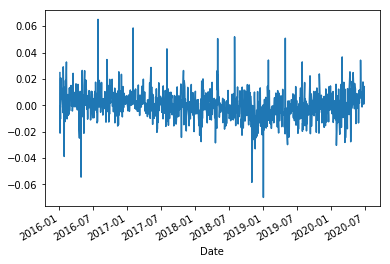

In [23]:
FF5.resid.plot()

In [25]:
FF5.resid.mean()

-1.436689408707376e-15

2. The sample covariance between the regressors and the OLS residuals is zero:

$$
\sum_{i=1}^{N} X_i \widehat{\epsilon}_i = 0.
$$


In [53]:
sum(FF5.resid.values * df_stock_factor['MKT'].values)

-7.109926796616817e-16

In [52]:
np.cov(FF5.resid.values, df_stock_factor['MKT'].values)

array([[1.25456703e-04, 5.17198916e-20],
       [5.17198916e-20, 1.54769773e-04]])

We see that both the sum and the sample covariance are very close to zero.

3. The point $(\overline{X}, \overline{Y})$ is always on the OLS regression line. In particular,

$$
\widehat{\beta}_0 + \widehat{\beta}_1 \overline{X} = \overline{Y}.
$$

However, these properties are not the only ones that justify the use of OLS instead of competing estimators. The main advantage of the OLS estimator is summarized by the Gauss–Markov theorem.


## Gauss–Markov Theorem

Under assumptions (UR.1)–(UR.3), the OLS estimator $\widehat{\boldsymbol{\beta}}$ is **BLUE**
(Best Linear Unbiased Estimator) and consistent.

---

## What Is an Estimator?

An **estimator** is a rule applied to a sample to produce an **estimate**.  
The estimator is the rule, and the estimate is the result.

The components of the acronym **BLUE** are explained below.

---

## OLS Estimators Are Linear

Using matrix notation,

$$
\mathbf{Y}=\mathbf{X}\boldsymbol{\beta}+\boldsymbol{\varepsilon}.
$$

The relationship is linear in $\mathbf{Y}$.

---

## OLS Estimators Are Unbiased

From the sample model,

$$
\widehat{\boldsymbol{\beta}}
=
(\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{Y}.
$$

Substituting $\mathbf{Y}=\mathbf{X}\boldsymbol{\beta}+\boldsymbol{\varepsilon}$,

$$
\begin{aligned}
\widehat{\boldsymbol{\beta}}
&=(\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top
(\mathbf{X}\boldsymbol{\beta}+\boldsymbol{\varepsilon}) \\
&=\boldsymbol{\beta}
+(\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\boldsymbol{\varepsilon}.
\end{aligned}
$$

Taking expectations,

$$
\begin{aligned}
\mathbb{E}(\widehat{\boldsymbol{\beta}})
&=\boldsymbol{\beta}
+\mathbb{E}\Big[
(\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\boldsymbol{\varepsilon}
\Big] \\
&=\boldsymbol{\beta}.
\end{aligned}
$$

since $\mathbb{E}(\boldsymbol{\varepsilon}\mid\mathbf{X})=\mathbf{0}$ by (UR.2).

Therefore,

$$
\mathbb{E}(\widehat{\boldsymbol{\beta}})=\boldsymbol{\beta},
$$

and OLS is unbiased.

Unbiasedness means that, over repeated samples, the average estimate converges to the true parameter.

---

## OLS Estimators Are Best (Efficient)

Among unbiased estimators, the one with the smallest variance is best.

From unbiasedness,

$$
\widehat{\boldsymbol{\beta}}-\boldsymbol{\beta}
=
(\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\boldsymbol{\varepsilon}.
$$

Thus,

$$
\begin{aligned}
\operatorname{Var}(\widehat{\boldsymbol{\beta}})
&=\mathbb{E}\Big[
(\widehat{\boldsymbol{\beta}}-\boldsymbol{\beta})
(\widehat{\boldsymbol{\beta}}-\boldsymbol{\beta})^\top
\Big] \\
&=(\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top
\mathbb{E}(\boldsymbol{\varepsilon}\boldsymbol{\varepsilon}^\top)
\mathbf{X}
(\mathbf{X}^\top\mathbf{X})^{-1}.
\end{aligned}
$$

Using (UR.3),

$$
\mathbb{E}(\boldsymbol{\varepsilon}\boldsymbol{\varepsilon}^\top)
=\sigma^2\mathbf{I},
$$

so

$$
\operatorname{Var}(\widehat{\boldsymbol{\beta}})
=
\sigma^2(\mathbf{X}^\top\mathbf{X})^{-1}.
$$

This variance is minimal among linear unbiased estimators.

---

## Estimating the Error Variance

The true error variance $\sigma^2$ is unknown and must be estimated.

The sample residual variance is

$$
\widehat{\sigma}^2
=
s^2
=
\frac{\widehat{\boldsymbol{\varepsilon}}^\top
\widehat{\boldsymbol{\varepsilon}}}{N-k}
=
\frac{1}{N-k}\sum_{i=1}^{N}\widehat{\epsilon}_i^2.
$$

This estimator is essential for inference, including hypothesis testing and confidence intervals.

---

## Standard Errors

Since $\widehat{\boldsymbol{\beta}}$ is random, its uncertainty is measured by its standard deviation.

The square roots of the diagonal elements of

$$
\widehat{\sigma}^2(\mathbf{X}^\top\mathbf{X})^{-1}
$$

are called the **standard errors** of the parameter estimates.


The square roots of the diagonal elements of the variance–covariance matrix
$\widehat{\operatorname{Var}}(\widehat{\boldsymbol{\beta}})$
are called the **standard errors (se)** of the corresponding OLS estimators
$\widehat{\boldsymbol{\beta}}$. They estimate the standard deviation of
$\widehat{\beta}_i$ around $\beta_i$:

$$
\operatorname{se}(\widehat{\beta}_i)
=
\sqrt{\widehat{\operatorname{Var}}(\widehat{\beta}_i)}.
$$

The standard errors describe the accuracy of an estimator (the smaller, the better).
They measure the **sampling variability** of the least squares estimates
$\widehat{\beta}_1$ and $\widehat{\beta}_2$ in repeated samples.

If many samples are collected, the OLS estimates will differ across samples.
Hence, the OLS estimators are **random variables** with their own sampling
distribution.

In [55]:
FF5.bse

# Note: the b in bse stands for the parameter vector β, and se - standard errors.

Intercept    0.000365
MKT          0.035705
SMB          0.063897
HML          0.057064
RMW          0.101819
CMA          0.149880
dtype: float64

## Confidence Intervals

In this section we will introduce the notion of interval estimation - a procedure for creating ranges of values, called confidence intervals, in which the unknown parameters are likely to be located. Confidence interval creation procedures rely heavily on (UR.4) assumption.

In [57]:
FF5.conf_int()

,0,1
Intercept,-0.005060,-0.003629
MKT,1.104115,1.244078
SMB,-0.363729,-0.113258
HML,-0.444311,-0.220624
RMW,0.269044,0.668167
CMA,-0.890928,-0.303408


## Hypothesis Testing

in practice, we usually want to answer very specific questions about the effects of specific variables:

Does income affect expenditure?
Do more years in education lead to an increase in wage?
Hypothesis tests use the information about a parameter from the sample data to answer such yes/no questions (though not necessarily in such strong certainty).

### The Null Hypothesis

The **null hypothesis** is denoted by $H_0$. For a univariate regression, it is stated as:

$$
H_0:\ \beta_i = c,
$$

where $c$ is a constant of interest.

When testing the null hypothesis, we either **reject** or **fail to reject** $H_0$.

> **The null hypothesis is presumed to be true until the data provide sufficient evidence to reject it.**

Failing to reject $H_0$ does not mean that it is true. Hypothesis testing does not determine which hypothesis is true. It only assesses whether there is sufficient evidence to reject the null.

---

### The Alternative Hypothesis

The alternative hypothesis is denoted by $H_1$.

For $H_0:\ \beta_i=c$, the alternative may be specified in three ways:

- $H_1:\ \beta_i>c$ (right-sided test)
- $H_1:\ \beta_i<c$ (left-sided test)
- $H_1:\ \beta_i\neq c$ (two-sided test)

Economic theory often motivates one-sided alternatives. For example, income is expected to increase food expenditure, so we may test:

$$
H_0:\ \beta_{\text{INCOME}}=0
\quad \text{vs.} \quad
H_1:\ \beta_{\text{INCOME}}>0.
$$

> We usually frame hypothesis testing in terms of the null. We reject or fail to reject $H_0$. We never “accept” it.

---

### The Test Statistic

The **test statistic** is computed under the assumption that $H_0$ is true. Under the null, its distribution is known.

For $H_0:\ \beta_i=c$, the $t$-statistic is

$$
t_i
=
\frac{\widehat{\beta}_i - c}{\operatorname{se}(\widehat{\beta}_i)}
\sim t_{(N-2)}.
$$

If the null is false, this statistic does not follow a $t$-distribution with $N-2$ degrees of freedom.

---

### The Rejection Regions

The **rejection region** contains values that are unlikely under $H_0$.

Its size is determined by the **significance level** $\alpha$, typically

$$
\alpha = 0.01,\ 0.05,\ \text{or}\ 0.10.
$$

To make a decision, we compare the test statistic to the critical value $t_c$.

> Reject $H_0$ if $t_i$ lies in the rejection region.

---

### Type I and Type II Errors

Two types of errors may occur:

- **Type I error**: Rejecting $H_0$ when it is true.

$$
\mathbb{P}(\text{Reject } H_0 \mid H_0 \text{ true}) = \alpha.
$$

- **Type II error**: Failing to reject $H_0$ when it is false.

Its probability depends on the true value of $\beta_i$ and is generally unknown.

Reducing $\alpha$ lowers the probability of Type I error but increases the probability of Type II error.

Type I errors are usually considered more severe.

---

### The $p$-Value

The **$p$-value** is the probability, under $H_0$, of observing a test statistic at least as extreme as the one obtained.

It allows inference without explicit comparison to critical values.

> Decision rule:

- If $p \leq \alpha$, reject $H_0$.
- If $p > \alpha$, fail to reject $H_0$.


In [58]:
FF5.pvalues

Intercept     1.147488e-32
MKT          3.858437e-237
SMB           1.896132e-04
HML           5.669656e-09
RMW           4.177710e-06
CMA           6.767988e-05
dtype: float64

## Goodness of Fit

To obtain accurate predictions of $Y$, we hope that the explanatory variable $X$
accounts for as much variation in $Y$ as possible. Ideally, variation in $X$
helps explain variation in $Y$.

Therefore, we need a way to **measure** how well our model performs, that is,
how much of the variation in $Y$ is explained by variation in $X$ through the model.
This is called a **goodness-of-fit** measure.

More generally, a goodness-of-fit measure quantifies how well the estimated model
fits the observed data. There are several such measures available in practice.


### R-squared ($R^2$)

It is often useful to compute a summary measure of how well the OLS regression
fits the data. This measure is called the **coefficient of determination**, $R^2$.

It is defined as the ratio of explained variation to total variation:

$$
R^2
=
\frac{\text{ESS}}{\text{TSS}}
=
1-\frac{\text{RSS}}{\text{TSS}}.
$$

It represents the proportion of variation in $Y$ that is explained by $X$ in the
regression model.

---

#### Interpretation

- The closer $R^2$ is to $1$, the closer the observed values $Y_i$ are to the fitted
  values $\widehat{Y}_i$. If $R^2=1$, the model provides a perfect fit.

- If there is no linear relationship between $Y$ and $X$, then $R^2=0$ in a
  univariate regression.

- For $0<R^2<1$, $R^2$ measures the proportion of variation in $Y$ around its mean
  that is explained by the regression.  
  For example, $R^2=0.17$ means that $17\%$ of the variation in $Y$ is explained by $X$.

---

#### Caveats When Using $R^2$

When comparing models using $R^2$, note the following:

- Comparisons are **not valid** across models with different transformations of
  the dependent variable. For example, models with $Y$ and $\log(Y)$ as dependent
  variables cannot be compared using $R^2$.

- $R^2$ does not measure predictive performance. A model may fit the data well
  but produce economically implausible forecasts.

- $R^2$ is based on sample data and does not indicate whether the model
  approximates the true population DGP.

- $R^2$ may be low if the error variance $\sigma^2$ is large or if the variance of
  $X$ is small.

- $R^2$ may be high even if the model is misspecified. For example, a linear model
  may yield a high $R^2$ even when the true relationship is nonlinear.

- Goodness of fit does not depend on the units of measurement of the variables.
  Comparisons of $R^2$ are valid when models share the same dependent variable,
  such as linear and log-linear models with dependent variable $Y$.

---

In practice, models should not be selected **solely** on the basis of $R^2$.
Other statistical and economic criteria must also be considered.


In [59]:
FF5.rsquared

0.6371536242060707

In [60]:
FF5.rsquared_adj

0.6355438354935865

### Regression Diagnostics and Graphics

In many empirical applications, we are uncertain whether the model has been
correctly specified. As discussed earlier, $R^2$ may be artificially small or
large regardless of specification. Therefore, regression diagnostics and
specification tests are essential.

For univariate regression, the most important assumptions are (UR.3) and (UR.4):

- $\operatorname{Var}(\epsilon_i\mid\mathbf{X})=\sigma_\epsilon^2,\ \forall i$
- $\operatorname{Cov}(\epsilon_i,\epsilon_j)=0,\ i\neq j$
- $\boldsymbol{\varepsilon}\mid\mathbf{X}\sim
  \mathcal{N}(\mathbf{0},\sigma_\epsilon^2\mathbf{I})$

---

### Definition of Residuals

The OLS residuals are defined as

$$
\begin{aligned}
\widehat{\boldsymbol{\varepsilon}}
&=\mathbf{Y}-\widehat{\mathbf{Y}} \\
&=\mathbf{Y}-\mathbf{X}\widehat{\boldsymbol{\beta}} \\
&=\mathbf{Y}-\mathbf{X}(\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{Y} \\
&=\Big[\mathbf{I}-\mathbf{X}(\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\Big]\mathbf{Y}.
\end{aligned}
$$

Hence,

$$
\mathbb{E}(\widehat{\boldsymbol{\varepsilon}}\mid\mathbf{X})=0.
$$

For simplicity, define

$$
\widehat{\boldsymbol{\varepsilon}}=(\mathbf{I}-\mathbf{H})\mathbf{Y},
\qquad
\mathbf{H}=\mathbf{X}(\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top.
$$

---

### Variance of the Residuals

The conditional variance–covariance matrix of the residuals is

$$
\begin{aligned}
\operatorname{Var}(\widehat{\boldsymbol{\varepsilon}}\mid\mathbf{X})
&=\operatorname{Var}\big((\mathbf{I}-\mathbf{H})\mathbf{Y}\mid\mathbf{X}\big) \\
&=(\mathbf{I}-\mathbf{H})\operatorname{Var}(\mathbf{Y}\mid\mathbf{X})
(\mathbf{I}-\mathbf{H})^\top \\
&=\sigma^2(\mathbf{I}-\mathbf{H}).
\end{aligned}
$$

This shows that residuals may have different variances (given by the diagonal
elements), even when the true errors have constant variance $\sigma^2$.

The variance of fitted values is smallest near the mean of $X$ and largest for
observations far from the mean.

---

## Residual Diagnostic Plots

Model adequacy can be examined using residual plots, including:

- Residuals $\widehat{\epsilon}_i$ versus fitted values $\widehat{Y}_i$
- Residuals $\widehat{\epsilon}_i$ versus $X_i$
- Q–Q plots, histograms, or boxplots of residuals

If assumptions (UR.2) and (UR.3) hold, these plots should show no systematic
patterns. The histogram and Q–Q plot should be approximately normal if (UR.4)
holds.

Residual plots are especially useful for detecting misspecified functional
forms.

Only models with the same dependent variable should be compared using residuals.
For example, comparing linear–linear and log–linear models is not meaningful.

---

## Transformations and Residual Behavior

Transformations may help address residual problems:

- Nonlinear patterns should be addressed before testing for heteroskedasticity.
- Transforming $Y$ mainly targets error-related problems and may address
  nonlinearity.
- Transforming $X$ primarily addresses nonlinearity.
- In some cases, transforming $X$ is sufficient to obtain normal errors.
- In other cases, transformations may not resolve nonlinearity.

---

### Interpreting Q–Q Plots

A Q–Q plot compares empirical quantiles with theoretical quantiles.
If the data are normally distributed, the plotted points should lie
approximately on a straight line.


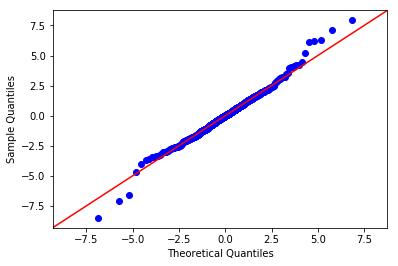

In [63]:
import statsmodels.api as sm
from matplotlib import pyplot as plt
import scipy.stats as stats

fig = sm.qqplot(FF5.resid.values, stats.t, distargs=(6,), fit=True, line="45")
plt.show()


## Residual Heteroskedasticity

If

$$
\operatorname{Var}(\epsilon_i \mid \mathbf{X})=\sigma_\epsilon^2,
\quad \forall i=1,\ldots,N,
$$

the residuals are **homoskedastic**. If this assumption is violated, the residuals
are **heteroskedastic**, meaning that their variance is not constant across
observations.

---

### Consequences of Heteroskedasticity

If heteroskedasticity is present:

- OLS parameter estimates remain **unbiased**.

- OLS estimates are no longer efficient, that is, they no longer have minimum
  variance. This occurs because OLS assigns equal weight to all observations,
  even though observations with larger error variance contain less information.

- The estimated error variance is **biased**, and therefore the standard errors
  are **biased**. This leads to biased test statistics and confidence intervals.

- Because of biased standard errors, we may fail to reject
  $H_0:\ \beta_i=0$ when it is false, resulting in a Type II error.

---

### Remedies for Heteroskedasticity

Several approaches can be used to address heteroskedasticity:

- Transforming the data, such as taking logarithms, which may help linearize the
  relationship and stabilize the variance.

- Using alternative estimation methods, such as **Weighted Least Squares (WLS)**,
  which assigns different weights to observations to account for non-constant
  variance.

- Correcting the standard errors while leaving the OLS estimates unchanged.
  **Heteroskedasticity-consistent (robust) standard errors**, such as White’s
  estimator, provide consistent variance estimates.


There are several methods for testing the presence of heteroskedasticity. Some
commonly used tests are the following.

---

### Goldfeld–Quandt Test

The **Goldfeld–Quandt test** divides the dataset into two subsets. Observations
with low values of the explanatory variable are placed in one subset, and those
with high values in another.

The subsets:

- Are not necessarily of equal size,
- Do not necessarily include all observations.

The test statistic is the ratio of the mean squared residuals from the two
subsamples. It follows an $F$ distribution under the null hypothesis of equal
variances.

This test requires that the data be **ordered** by a known explanatory variable.

If the error variance depends on an unknown or unobserved variable, the
Goldfeld–Quandt test provides little guidance. It also assumes that the variance
is a monotonic function of the ordering variable.

For example, if the variance follows a quadratic pattern, the test may fail to
detect heteroskedasticity.

Moreover, the Goldfeld–Quandt test is not robust to specification errors. It
cannot distinguish between heteroskedasticity and problems such as omitted
variables or incorrect functional form.

---

### Breusch–Pagan Test

After estimating

$$
Y=\beta_0+\beta_1 X+\epsilon,
$$

compute the residuals $\widehat{\epsilon}_i$.

Under homoskedasticity,

$$
\operatorname{Var}(\epsilon_i\mid\mathbf{X})=\sigma_\epsilon^2.
$$

If this assumption fails, $\widehat{\epsilon}_i^2$ may depend on $X_i$.

The Breusch–Pagan test is based on the auxiliary regression

$$
\widehat{\epsilon}_i^2
=
\gamma_0+\gamma_1 X_i+v_i.
$$

The hypotheses are

$$
\begin{aligned}
H_0&:\ \gamma_1=0 \quad \text{(homoskedasticity)},\\
H_1&:\ \gamma_1\neq 0 \quad \text{(heteroskedasticity)}.
\end{aligned}
$$

The test statistic is

$$
LM = N\cdot R^2_{\widehat{\epsilon}},
$$

where $R^2_{\widehat{\epsilon}}$ is the $R^2$ from the auxiliary regression.

Under $H_0$,

$$
LM \sim \chi^2_1.
$$

A limitation of the Breusch–Pagan test is that it assumes a **linear**
relationship between the regressors and the error variance. Failure to reject
$H_0$ does not rule out nonlinear heteroskedasticity.

---

### White Test

The **White test** is more general than the Breusch–Pagan test, as it allows for
nonlinear effects of the regressors on the error variance.

The auxiliary regression may include:

- Squared terms,
- Cross-products,
- Higher-order terms.

The test statistic is again

$$
LM = N\cdot R^2_{\widehat{\epsilon}}.
$$

The difference from the Breusch–Pagan test is that the auxiliary regression may be
nonlinear.

A drawback of the White test is that it may lose power when the model contains
many explanatory variables.


In [73]:
import statsmodels.stats.diagnostic as sm_diagnostic

# Breusch–Pagan Test
sm_diagnostic.het_breuschpagan(resid = FF5.resid.values, exog_het = sm.add_constant(FF5.resid.values))

(4.736381826174274,
 0.029531116461051936,
 4.747868990115543,
 0.02954045766211842)

In [74]:
# White Test
print(sm_diagnostic.het_white(resid = FF5.resid.values, exog = sm.add_constant(FF5.resid.values)))

(1133.0, 9.379420394983054e-247, 7.973561307442355e+29, 0.0)


## Residual Autocorrelation

If

$$
\operatorname{Cov}(\epsilon_i,\epsilon_j)\neq 0
\quad \text{for some } i\neq j,
$$

the errors are correlated. Autocorrelation is frequently encountered in
time-series models.

Assume that the model is

$$
\begin{aligned}
Y_t &= \beta_0+\beta_1 X_t+\epsilon_t, \\
\epsilon_t &= \rho\,\epsilon_{t-1}+u_t,
\qquad |\rho|<1,\quad u_t\sim\mathcal{N}(0,\sigma^2).
\end{aligned}
$$

Then the model has **autocorrelated** (or **serially correlated**) errors.

In this case,

$$
\begin{aligned}
\operatorname{Cov}(\epsilon_t,\epsilon_{t-1})
&=\operatorname{Cov}(\rho\epsilon_{t-1}+u_t,\epsilon_{t-1}) \\
&=\rho\,\operatorname{Var}(\epsilon_{t-1}) \\
&=\rho\sigma^2 \neq 0.
\end{aligned}
$$

Estimating the model by OLS while ignoring autocorrelation still yields unbiased
and consistent estimators, but they are inefficient and their variances are
biased.

Autocorrelation may also arise from model misspecification.

---

## Tests for Autocorrelation

Several tests are available for detecting autocorrelation.

---

### Durbin–Watson Test

The hypotheses are

$$
\begin{aligned}
H_0&:\ \text{errors are serially uncorrelated},\\
H_1&:\ \text{errors follow an AR(1) process}.
\end{aligned}
$$

The test statistic is

$$
d=
\frac{\sum_{i=2}^{N}(\widehat{\epsilon}_i-\widehat{\epsilon}_{i-1})^2}
{\sum_{i=1}^{N}\widehat{\epsilon}_i^2}.
$$

The statistic satisfies $0\le d\le 4$.

- $d\approx 2$ indicates no autocorrelation.
- Values far from $2$ indicate serial correlation.

---

### Breusch–Godfrey Test

The Breusch–Godfrey test allows for higher-order autocorrelation and applies even
when lagged dependent variables are included.

Consider

$$
Y_i=\beta_0+\beta_1 X_i+\epsilon_i.
$$

After estimating the model by OLS, run the auxiliary regression

$$
\widehat{\epsilon}_i
=
\alpha_0+\alpha_1 X_i
+\rho_1\widehat{\epsilon}_{i-1}
+\rho_2\widehat{\epsilon}_{i-2}
+\cdots
+\rho_p\widehat{\epsilon}_{i-p}
+u_i.
$$

The hypotheses are

$$
\begin{aligned}
H_0&:\ \rho_1=\rho_2=\cdots=\rho_p=0,\\
H_1&:\ \rho_j\neq 0 \text{ for some } j.
\end{aligned}
$$

The test statistic is

$$
LM=(N-p)R^2 \sim \chi_p^2
$$

under $H_0$, where $R^2$ is from the auxiliary regression.

---

### Additional Tests

Another commonly used test is the **Ljung–Box test**, which examines the joint
null hypothesis of no autocorrelation at multiple lags.


In [26]:
from statsmodels.stats.stattools import durbin_watson
# Durbin–Watson Test
print(durbin_watson(FF5.resid.values))

1.6737921626623802


In [28]:
from statsmodels.stats.diagnostic import acorr_breusch_godfrey
# Breusch-Godfrey Test
print(acorr_breusch_godfrey(FF5, nlags = 2))

(40.17074024060269, 1.892494342030728e-09, 20.67827145690064, 1.5173694149624436e-09)


## Residual Normality Test

The normality assumption is required to obtain valid $p$-values and critical
$t$-values when testing hypotheses such as

$$
H_0:\ \beta_j=c,
$$

especially for significance testing with $c=0$.

Suppose we want to test whether the residuals $z_1,\ldots,z_N$ follow a normal
distribution. The hypotheses are

$$
\begin{aligned}
H_0&:\ \text{residuals are normally distributed},\\
H_1&:\ \text{residuals are not normally distributed}.
\end{aligned}
$$

---

## Normality Tests

Several tests are available for assessing normality.

---

### Anderson–Darling Test

The test statistic is

$$
A^2
=
-N-\sum_{i=1}^{N}\frac{2i-1}{N}
\Big[
\log F(z_{(i)})
+
\log\big(1-F(z_{(N+1-i)})\big)
\Big],
$$

where $z_{(i)}$ are the ordered observations and $F(\cdot)$ is the cumulative
distribution function of the hypothesized distribution.

The statistic is compared with tabulated critical values. Empirical evidence
suggests that the Anderson–Darling test performs well, though it is typically
slightly less powerful than the Shapiro–Wilk test.

---

### Shapiro–Wilk Test

The test statistic is

$$
W
=
\frac{\left(\sum_{i=1}^{N} a_i z_{(i)}\right)^2}
{\sum_{i=1}^{N}(z_i-\overline{z})^2},
$$

where $z_{(i)}$ is the $i$th smallest observation and the weights $a_i$ depend on
the moments of the ordered sample.

Small values of $W$ lead to rejection of normality. Monte Carlo studies show that
this test has very high power.

---

### Kolmogorov–Smirnov Test

The test statistic is

$$
D=\max\{D^+,D^-\},
$$

where

$$
\begin{aligned}
D^+&=\max_i\left(\frac{i}{N}-F(z_{(i)})\right),\\
D^-&=\max_i\left(F(z_{(i)})-\frac{i-1}{N}\right).
\end{aligned}
$$

Here, $F(\cdot)$ is the theoretical distribution function.

The **Lilliefors test** is a special case of this procedure for normality when
parameters are estimated.

---

### Cramér–von Mises Test

The test statistic is

$$
W
=
N\omega^2
=
\frac{1}{12N}
+
\sum_{i=1}^{N}
\left(
\frac{2i-1}{2N}-F(z_{(i)})
\right)^2.
$$

Large values of $W$ indicate departures from normality.

---

### Jarque–Bera Test (Large Samples)

The Jarque–Bera statistic is

$$
JB
=
\frac{N-k+1}{6}
\left(
S^2+\frac{(C-3)^2}{4}
\right),
$$

where

$$
\begin{aligned}
S&=
\frac{\frac{1}{N}\sum_{i=1}^{N}(z_i-\overline{z})^3}
{\left(\frac{1}{N}\sum_{i=1}^{N}(z_i-\overline{z})^2\right)^{3/2}}
=
\frac{\widehat{\mu}_3}{\widehat{\sigma}^3},\\[6pt]
C&=
\frac{\frac{1}{N}\sum_{i=1}^{N}(z_i-\overline{z})^4}
{\left(\frac{1}{N}\sum_{i=1}^{N}(z_i-\overline{z})^2\right)^2}
=
\frac{\widehat{\mu}_4}{\widehat{\sigma}^4}.
\end{aligned}
$$

Here, $N$ is the sample size, $S$ is skewness, $C$ is kurtosis, and $k$ is the number
of regressors.

Under normality,

$$
JB \sim \chi_2^2.
$$


In [25]:
from statsmodels.stats.stattools import jarque_bera
jarque_bera(FF5.resid.values)

(1163.04560231688,
 2.804505886896713e-253,
 0.1707597112963196,
 7.958348312142612)

## Standardized Residuals

When comparing residuals across observations, it is important to account for the
fact that their variances may differ. One way to do so is to divide each residual
by an estimate of its standard deviation.

This leads to the **standardized residuals**:

$$
s_i
=
\frac{\widehat{\epsilon}_i}
{\widehat{\sigma}\sqrt{1-h_{ii}}},
$$

where $h_{ii}$ is the $i$th diagonal element of the hat matrix $\mathbf{H}$.

Standardized residuals are useful for detecting outliers. In practice,
observations with $|s_i|>2$ should be examined more closely.
